<a href="https://colab.research.google.com/github/Manasvi87/Pluto-academy-Internship/blob/main/Project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import modules such as pandas, numpy, matplotlib, LinearRegression, DecisionTreeRegressor, RandomForestRegressor and evaluation metrices such as mean_squared_error, mean_absolute_error, r2_score etc.



In [11]:
from google.colab import drive
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


Step1:Load, Explore & Preprocess- Load the dataset from google drive

In [2]:
drive.mount('/content/drive')
drive_file_path = '/content/drive/My Drive/Colab Notebooks/train.csv'
dataframe = pd.read_csv(drive_file_path)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Check for missing values

In [3]:
missing = dataframe.isnull().sum().sort_values(ascending=False)
print(missing.head(10))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageQual        81
GarageFinish      81
GarageType        81
dtype: int64


Encode categorical values because machine learning models only understand numbers, not text (e.g., "Neighbourhood")

In [31]:
dataframe = pd.get_dummies(dataframe, drop_first=True)


In [34]:
# 1. Handle missing values FIRST

# Numerical columns
num_cols = dataframe.select_dtypes(include=['int64', 'float64']).columns
dataframe[num_cols] = dataframe[num_cols].fillna(dataframe[num_cols].mean())

# Categorical columns
cat_cols = dataframe.select_dtypes(include='object').columns
dataframe[cat_cols] = dataframe[cat_cols].fillna('Unknown')

# 2. Then encode
dataframe = pd.get_dummies(dataframe, drop_first=True)

# 3. Split
X = dataframe.drop('SalePrice', axis=1)
y = dataframe['SalePrice']

split into train/test sets (80/20)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(1168, 245) (292, 245)


Step2: Feature Engineering- Identify which features matter most using correlation analysis

Correlation analysis is used to identify the relationship between features and the target variable (SalePrice). Features with higher absolute correlation values are considered more important. Top features of correlation analysis include OverallQual, GrLivArea, and GarageCars, indicating a strong influence on house prices.

In [9]:
correlation = dataframe.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
correlation.head(10)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


Visual for Correlation Analysis

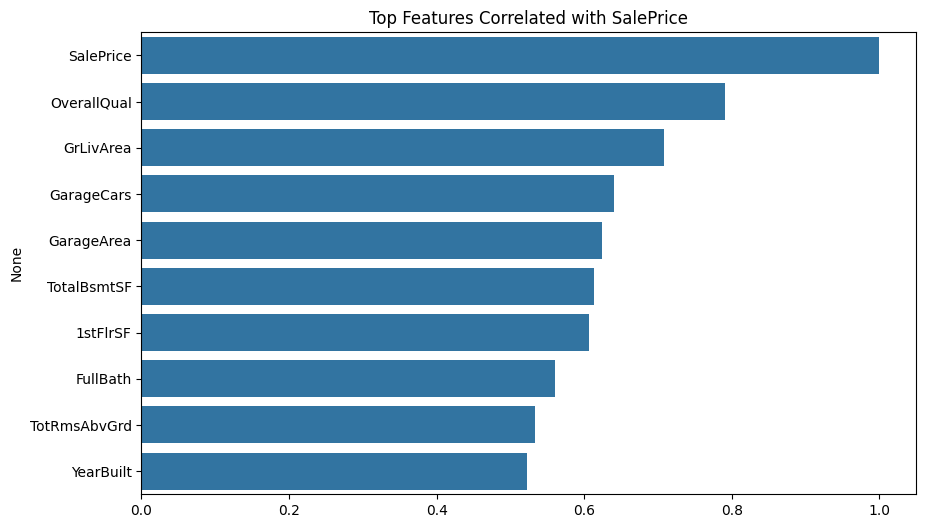

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.head(10).values, y=correlation.head(10).index)
plt.title("Top Features Correlated with SalePrice")
plt.show()

Drop irrelevant features

1. **Common Irrelevant Feature (Id):** because it is just a unique identifier and has no relationship with SalesPrice and can mislead models (especially tree-based ones).

In [13]:
dataframe = dataframe.drop(['Id'], axis=1)

2. **Features with Too Many Missing Values:** because large portion of values are missing (often >80%), imputing would introduce noise and these features contribute very little useful information

In [15]:
missing_percent = (dataframe.isnull().sum() / len(dataframe)) * 100
missing_percent

,0
MSSubClass,0.000000
LotFrontage,17.739726
LotArea,0.000000
OverallQual,0.000000
OverallCond,0.000000
...,...
SaleCondition_AdjLand,0.000000
SaleCondition_Alloca,0.000000
SaleCondition_Family,0.000000
SaleCondition_Normal,0.000000


In [18]:
dataframe = dataframe.drop(['LotFrontage'], axis=1)

3. **Low Correlation Features:** because they form a very weak relationship with the target (SalePrice), they add complexity without improving prediction and can increase overfitting.

In [21]:
low_corr = correlation[abs(correlation) < 0.1].index
columns_to_drop_from_df = [col for col in low_corr if col in dataframe.columns]
dataframe = dataframe.drop(columns_to_drop_from_df, axis=1)

4. **Redundant Features (Multicollinearity):** Example- GarageCars and GarageArea because they affect Linear Regression performance and are very similar information

In [22]:
dataframe = dataframe.drop(['GarageArea'], axis=1)

5. **Categorical Features with Too Many Unique Values:** Example- Neighborhood because it creates too many dummy variables, increases dimensionality and may not significantly improve model.

In [25]:
#Identify Categotical Columns
categorical_cols = dataframe.select_dtypes(include='object').columns
#Count Unique Values in Each Column
unique_counts = dataframe[categorical_cols].nunique()
unique_counts
#Find Columns with Too Many Unique Values
high_cardinality = unique_counts[unique_counts > 20]
high_cardinality

,0


This means that there are NO categorical columns with more than 20 unique values and there are no high-cardinality categorical features so there is nothing to drop based on this condition

Step3: Train 3 different models
1. Linear Regression + Decision Tree + Random Forest

In [38]:
#Train Linear regressor
lr = LinearRegression()
nan_rows_train = X_train[X_train.isnull().any(axis=1)]
if not nan_rows_train.empty:
    # Get the indices of rows without NaNs
    clean_indices_train = X_train.dropna().index
    X_train_cleaned = X_train.loc[clean_indices_train]
    y_train_cleaned = y_train.loc[clean_indices_train]
else:
    X_train_cleaned = X_train
    y_train_cleaned = y_train

# Fit the model with the cleaned training data
lr.fit(X_train_cleaned, y_train_cleaned)
nan_rows_test = X_test[X_test.isnull().any(axis=1)]
if not nan_rows_test.empty:
    clean_indices_test = X_test.dropna().index
    X_test_cleaned = X_test.loc[clean_indices_test]
else:
    X_test_cleaned = X_test

y_pred_lr = lr.predict(X_test_cleaned)

This code is basically making sure that the model doesn’t crash because of missing values by carefully removing any problematic rows before training and prediction. First, it checks the training data (X_train) to see if any rows contain missing values, and if they do, it drops those rows completely and keeps only the clean ones; at the same time, it also filters the target variable (y_train) using the same indices so both stay properly aligned. If there are no missing values, it just uses the original data. Then it trains the Linear Regression model on this cleaned dataset. After that, it repeats a similar process for the test data (X_test), removing any rows that contain missing values before making predictions, so the model doesn’t encounter NaNs during prediction either. So, instead of fixing missing values, this approach just avoids them entirely by throwing away any rows that contain them, which prevents errors but can reduce the amount of data available and may cause mismatches later when comparing predictions with the original test labels.

In [39]:
#Train decision tree regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

This code is training and using a Decision Tree model to make predictions in a very straightforward way. First, it creates a Decision Tree Regressor with a fixed random_state so that the results are consistent every time you run the code. Then, it trains the model using the training data (X_train as input features and y_train as the target), where the model learns patterns by splitting the data into smaller groups based on feature values, essentially creating a tree of decision rules. After the model has learned from the training data, it uses this trained model to predict house prices for the unseen test data (X_test). In simple terms, the model learns a set of “if-else” rules from the training data and then applies those rules to estimate the target values for new data points.

In [40]:
#Train random forest regressor
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

This code is using a Random Forest model, which is an advanced version of a Decision Tree, to make predictions. First, it creates a Random Forest Regressor with a fixed random_state so that the results are consistent every time the code is run. Then, it trains the model using the training data (X_train and y_train). Instead of building just one decision tree like the previous model, Random Forest builds many decision trees on different subsets of the data and combines their results, which helps improve accuracy and reduce overfitting. After training, the model is used to predict the target values (like house prices) for the test data (X_test).

In [42]:
#Evaluate models
def evaluate(y_test_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("MSE:", mean_squared_error(y_test_true, y_pred))
    print("MAE:", mean_absolute_error(y_test_true, y_pred))
    print("R2 Score:", r2_score(y_test_true, y_pred))
    print()
y_test_lr = y_test.loc[X_test_cleaned.index]
# Evaluate all models
evaluate(y_test_lr, y_pred_lr, "Linear Regression")
evaluate(y_test, y_pred_dt, "Decision Tree")
evaluate(y_test, y_pred_rf, "Random Forest")

--- Linear Regression ---
MSE: 2323982172.7632637
MAE: 22337.157494281433
R2 Score: 0.7199205700476697

--- Decision Tree ---
MSE: 1501598840.260274
MAE: 25726.54794520548
R2 Score: 0.8042327275659711

--- Random Forest ---
MSE: 804262530.9109637
MAE: 17579.3504109589
R2 Score: 0.8951462416086858



This code is used to evaluate how well each of your trained models is performing by comparing their predictions with the actual values. First, a function called evaluate is defined, which takes the true test values, the predicted values, and the model name as inputs, and then prints three important metrics: Mean Squared Error (MSE), which measures how large the prediction errors are (giving more weight to bigger mistakes); Mean Absolute Error (MAE), which shows the average absolute difference between predicted and actual values; and R² score, which indicates how well the model explains the variation in the data (closer to 1 is better). Since some rows with missing values for Linear Regression were removed, y_test was correctly adjusted using X_test_cleaned.index so that the true values match the predictions in size and order.

Step 4 :Evaluate & Compare All Models

In [43]:
#Compute Metrics for All Models

# Linear Regression (use aligned y_test)
rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)
r2_lr = r2_score(y_test_lr, y_pred_lr)

# Decision Tree
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

# Random Forest
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [44]:
#Create Comparison Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'RMSE': [rmse_lr, rmse_dt, rmse_rf],
    'MAE': [mae_lr, mae_dt, mae_rf],
    'R2 Score': [r2_lr, r2_dt, r2_rf]
})

results

,Model,RMSE,MAE,R2 Score
0,Linear Regression,48207.698273,22337.157494,0.719921
1,Decision Tree,38750.468904,25726.547945,0.804233
2,Random Forest,28359.522755,17579.350411,0.895146


Step 5: Best Model Analysis &  residual plot (regression)

The best model is the one with:


Lowest RMSE


Lowest MAE


Highest R²


Among the three models, the Random Forest Regressor performed the best as it achieved the lowest RMSE and MAE along with the highest R² score.




*   Random Forest performed better because it combines multiple decision trees, which helps capture complex and non-linear relationships in the data.
*  It reduces overfitting compared to a single Decision Tree by averaging predictions from multiple trees.


*   This results in more stable and accurate predictions.

**Residual = Actual − Predicted**






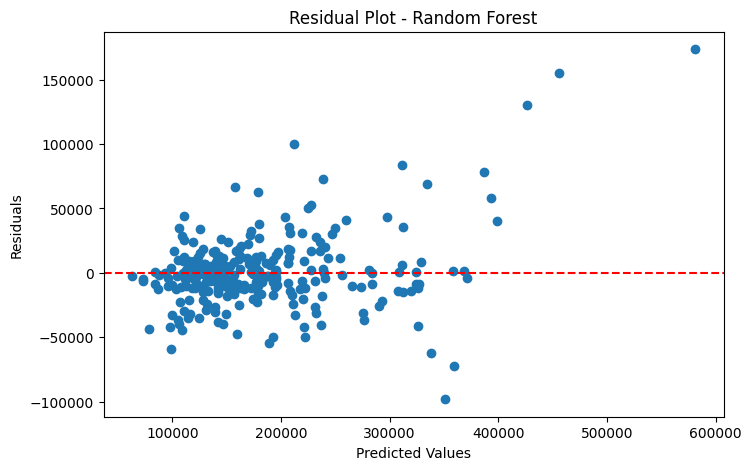

In [45]:
# Residuals
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,5))
plt.scatter(y_pred_rf, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest")

plt.show()

 **5-line written conclusion explaining the best model choice**


*   The Random Forest model performed the best among all three models based on the evaluation metrics.
*   It had the lowest RMSE and MAE, meaning its prediction errors were smaller than the others.


*   It also achieved the highest R² score, showing it explains the data more effectively.
*  This is because Random Forest combines multiple decision trees, making it more accurate and less prone to overfitting.


*   Overall, it provides more reliable and consistent predictions compared to Linear Regression and Decision Tree.




